In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import os
from PIL import Image
import time
from tempfile import TemporaryDirectory


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import torch 
from torch.optim import lr_scheduler
from torch import nn,optim
import torch.backends.cudnn as cudnn
from torchvision import datasets,transforms,models
from torch.utils.data import DataLoader,Dataset
from torchvision.utils import make_grid
cudnn.benchmark = True
plt.ion()   # interactive mode

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
data_path = "/kaggle/input/ai-generated-images-vs-real-images/"
aidata = os.path.join(data_path,"AiArtData/AiArtData")
realdata = os.path.join(data_path,'RealArt/RealArt')
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [7]:
class CustomDataset(Dataset):
    def __init__(self,X,y,transform=None):
        self.X = X
        self.y = y
        self.transform = transform
    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = Image.open(self.X[idx])
        img = img.convert("RGB")
        label = self.y[idx]
        
        if self.transform:
            img = self.transform(img)
        
        return img,label

data_transform = {
    'train':transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    "val":transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
}

def image_to_tensor(img_path,transform):
    image = Image.open(img_path)
    tensor = transform(image).unsqueeze(0)
    return tensor.to(device)

def make_label(class_1:list,class_2:list):
    class_1_name,class_1_dir = class_1
    class_2_name,class_2_dir = class_2
    label_ = []
    img_file = []
    mode = []
    
    def check(ext,img_path,mode):
        if ext in [".jpg",'.jpeg','.png'] and os.path.exists(img_path) and mode in ["RGB","RGBA"]:
            return True
        return False
    
    for i in os.listdir(class_1_dir):
        _,m = os.path.splitext(i)
        path = os.path.join(class_1_dir,i)
        im = Image.open(path)
        if not check(m,path,im.mode):
            continue
        img_file.append(path)
        mode.append(m)
        label_.append(class_1_name)
    
    for i in os.listdir(class_2_dir): 
        _,m = os.path.splitext(i)
        path = os.path.join(class_2_dir,i)
        im = Image.open(path)
        md = im.mode
        if not check(m,path,md):
            continue
        img_file.append(path)
        mode.append(m)
        label_.append(class_2_name)

    return pd.DataFrame({'img_file':img_file,'label':label_,'mode':mode})

In [8]:
df = make_label([0,aidata],[1,realdata])
df

,img_file,label,mode
0,/kaggle/input/ai-generated-images-vs-real-imag...,0,.jpg
1,/kaggle/input/ai-generated-images-vs-real-imag...,0,.jpg
2,/kaggle/input/ai-generated-images-vs-real-imag...,0,.jpg
3,/kaggle/input/ai-generated-images-vs-real-imag...,0,.jpg
4,/kaggle/input/ai-generated-images-vs-real-imag...,0,.jpg
...,...,...,...
935,/kaggle/input/ai-generated-images-vs-real-imag...,1,.jpg
936,/kaggle/input/ai-generated-images-vs-real-imag...,1,.jpeg
937,/kaggle/input/ai-generated-images-vs-real-imag...,1,.jpg
938,/kaggle/input/ai-generated-images-vs-real-imag...,1,.jpeg


In [9]:
from sklearn.model_selection import train_test_split

X = df['img_file'].values
y = df['label'].values
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2,stratify=y)
X_train.shape,X_test.shape

((752,), (188,))

In [10]:
image_datasets = {'train':CustomDataset(X=X_train,y=y_train,transform=data_transform['train']),
                  'val':CustomDataset(X=X_test,y=y_test,transform=data_transform['val'])}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
dataloaders = {'train':DataLoader(image_datasets['train'],batch_size=4,num_workers=2),'val':DataLoader(image_datasets['val'],batch_size=4,num_workers=2)}
class_names = {0:'Ai Image',1:'Real Image'}

In [11]:
class_names[image_datasets['train'][0][1]]

'Ai Image'

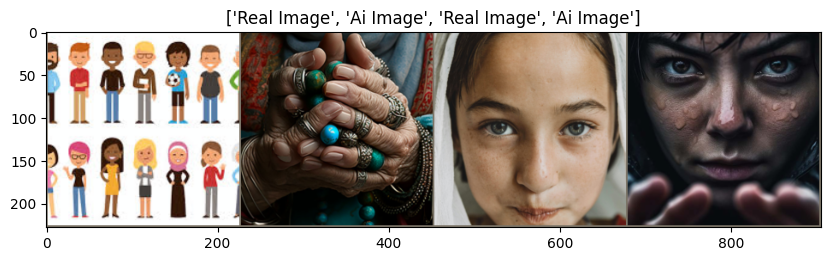

In [12]:
def imshow(inp, title=None):
    plt.figure(figsize=(10,5))
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['val']))
classes = classes.tolist()

# Make a grid from batch
out = make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [13]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()
    acc_ = []
    loss_ = []

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
                acc_.append(epoch_acc)
                loss_.append(epoch_loss)

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path))
    return model,acc_,loss_

# Unfreeze Feature Extractor

In [14]:
model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to ``nn.Linear(num_ftrs, len(class_names))``.
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s]


In [ ]:
model_ft,acc,loss = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

Epoch 0/24
----------
train Loss: 0.2548 Acc: 0.8989
val Loss: 0.5566 Acc: 0.7872

Epoch 1/24
----------
train Loss: 0.2432 Acc: 0.8949
val Loss: 0.5573 Acc: 0.7872

Epoch 2/24
----------
train Loss: 0.2342 Acc: 0.9029
val Loss: 0.5751 Acc: 0.7926

Epoch 3/24
----------
train Loss: 0.2504 Acc: 0.8936
val Loss: 0.5554 Acc: 0.7979

Epoch 4/24
----------
train Loss: 0.2389 Acc: 0.9069
val Loss: 0.5621 Acc: 0.7819

Epoch 5/24
----------
train Loss: 0.2418 Acc: 0.9109
val Loss: 0.5604 Acc: 0.7766

Epoch 6/24
----------
train Loss: 0.2525 Acc: 0.8883
val Loss: 0.5562 Acc: 0.7926

Epoch 7/24
----------
train Loss: 0.2695 Acc: 0.8790
val Loss: 0.5463 Acc: 0.7872

Epoch 8/24
----------


Accuracy: 0.7926
Precision: 0.7922
Recall: 0.7262
F1-score: 0.7578
Confusion Matrix:
[[88 16]
 [23 61]]


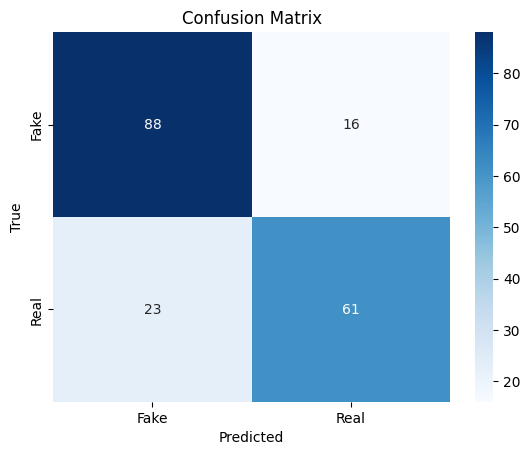

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming model and dataloaders are already defined

def evaluate_model(model, dataloader, device):
    model.eval()  # Set the model to evaluation mode
    y_true = []
    y_pred = []

    with torch.no_grad():  # No need to compute gradients during testing
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # Calculate the classification metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # Print the classification metrics
    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1-score: {f1:.4f}')

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    print('Confusion Matrix:')
    print(cm)

    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# After training your model, evaluate it on the validation set
evaluate_model(model_ft, dataloaders['val'], device)


In [17]:
import torch
from PIL import Image
from torchvision import transforms

# Define the same transformations as in the previous code
data_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Define class names (for real vs AI image classification)
class_names = {0: 'Ai Image', 1: 'Real Image'}

# Function to predict the class of a single image
def predict_image(image_path, model, device):
    # Open the image and convert it to RGB
    image = Image.open(image_path).convert("RGB")
    
    # Apply the transformations
    image = data_transform(image).unsqueeze(0)  # Add batch dimension
    
    # Move the image tensor to the correct device (CPU or GPU)
    image = image.to(device)

    # Set the model to evaluation mode
    model.eval()

    # Get the model's prediction
    with torch.no_grad():  # Disable gradient calculation for inference
        outputs = model(image)
        _, predicted_class = torch.max(outputs, 1)  # Get the index of the highest probability

    # Map the predicted class index to the class name
    prediction = class_names[predicted_class.item()]
    
    return prediction

# Example usage:
image_path = '/kaggle/input/ai-generated-images-vs-real-images/AiArtData/AiArtData/-s-fluffy-fur-and-round-features-immediately-melted-the-viewer-s-heart-photo.jpg'  # Replace with your image path
prediction = predict_image(image_path, model_ft, device)
print(f"The uploaded image is classified as: {prediction}")


The uploaded image is classified as: Ai Image


In [18]:
import torch
from PIL import Image
from torchvision import transforms
import torch.nn.functional as F

# Define the same transformations as in the previous code
data_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Define class names (for real vs AI image classification)
class_names = {0: 'Ai Image', 1: 'Real Image'}

# Function to predict the class of a single image and provide the likelihood (probability)
def predict_image(image_path, model, device):
    # Open the image and convert it to RGB
    image = Image.open(image_path).convert("RGB")
    
    # Apply the transformations
    image = data_transform(image).unsqueeze(0)  # Add batch dimension
    
    # Move the image tensor to the correct device (CPU or GPU)
    image = image.to(device)

    # Set the model to evaluation mode
    model.eval()

    # Get the model's prediction
    with torch.no_grad():  # Disable gradient calculation for inference
        outputs = model(image)
        probs = F.softmax(outputs, dim=1)  # Apply softmax to get probabilities
        _, predicted_class = torch.max(outputs, 1)  # Get the index of the highest probability

    # Map the predicted class index to the class name
    prediction = class_names[predicted_class.item()]
    
    # Get the probability of the image being AI-generated (class 0)
    ai_image_prob = probs[0][0].item()  # Probability for the 'Ai Image' class

    return prediction, ai_image_prob

# Example usage:
image_path = '/kaggle/input/ai-generated-images-vs-real-images/AiArtData/AiArtData/-s-fluffy-fur-and-round-features-immediately-melted-the-viewer-s-heart-photo.jpg'  # Replace with your image path
prediction, ai_image_prob = predict_image(image_path, model_ft, device)
print(f"The uploaded image is classified as: {prediction}")
print(f"Probability of the image being AI-generated: {ai_image_prob * 100:.2f}%")

image_path = '/kaggle/input/ai-generated-images-vs-real-images/RealArt/RealArt/0182.png'  # Replace with your image path
prediction, ai_image_prob = predict_image(image_path, model_ft, device)
print(f"The uploaded image is classified as: {prediction}")
print(f"Probability of the image being AI-generated: {ai_image_prob * 100:.2f}%")

#image_path = '/kaggle/input/sampletestimage/download.jpg'
#prediction, ai_image_prob = predict_image(image_path, model_ft, device)
#print(f"The uploaded image is classified as: {prediction}")
#print(f"Probability of the image being AI-generated: {ai_image_prob * 100:.2f}%")




The uploaded image is classified as: Ai Image
Probability of the image being AI-generated: 98.55%
The uploaded image is classified as: Real Image
Probability of the image being AI-generated: 0.34%


In [ ]:
torch.save(model_ft,'/kaggle/working/resnet_realvsai.h5')
print(f"Model saved successfully!!!")

# Freeze Feature Extractor

In [ ]:
model_conv = models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

model_conv,acc,loss = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=25)